# Mixed distributions in QMCPy

A mixture can be generated by using one variable $V$ to decide which transformation is applied. This creates a discontinuity when $V$ crosses $p$. The question here is whether that particular discontinuity causes a serious problem for QMC convergence.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/qmcpy/blob/develop/demos/mixed_distributions.ipynb)

In [1]:
# @title Execute this cell to install dependencies
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
if IN_COLAB:
    !git clone -q --depth 1 --branch feature/mixed-distribution https://github.com/QMCSoftware/qmcpy.git /content/qmcpy
    !pip install -q -e /content/qmcpy

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

from qmcpy import DigitalNetB2, Gaussian, Mixture

plt.style.use("seaborn-v0_8-whitegrid")

## 1. Mixture construction

Use $U$ to generate the continuous input
$$
Z=S(U).
$$
Use the last coordinate, $V$, to decide which transformation to apply:
$$
C(V)=
\begin{cases}
1, & V\le p,\\
2, & V>p,
\end{cases}
\qquad
X=T_{C(V)}(Z).
$$
So $U$ gives us $Z$, and $V$ decides whether we apply $T_1$ or $T_2$. When $V$ crosses $p$, the transformation changes. That is the discontinuity we want to examine, and its boundary is in one coordinate.

Alternatively, we can compute the two component integrals separately,
$$
I_1=\int f(T_1(S(U)))\,dU,
\qquad
I_2=\int f(T_2(S(U)))\,dU,
$$
and then combine them as
$$
I=pI_1+(1-p)I_2.
$$

## 2. Generating mixture samples

QMCPy's `Mixture` class uses this construction to generate samples. Here the two components are Gaussian and $p=0.3$.

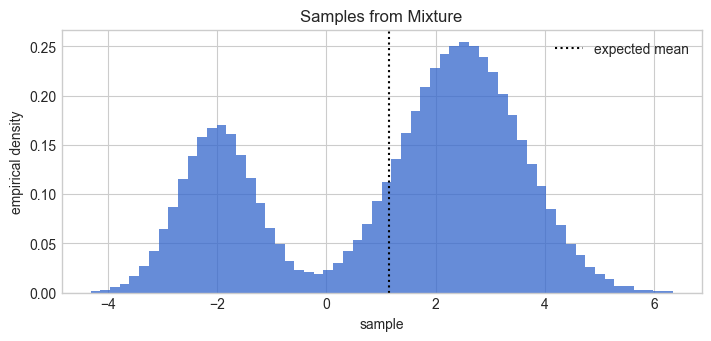

empirical sample mean: 1.149730
expected mixture mean: 1.150000


In [3]:
mu1, sigma1 = -2.0, 0.7
mu2, sigma2 = 2.5, 1.1
p = 0.3

components = [
    Gaussian(DigitalNetB2(1, seed=20260912), mean=mu1, covariance=sigma1**2),
    Gaussian(DigitalNetB2(1, seed=20260913), mean=mu2, covariance=sigma2**2),
]
mixture = Mixture(
    DigitalNetB2(2, seed=20260914),
    components,
    [p, 1 - p],
)
samples = mixture(4096)[:, 0]
expected_mean = p * mu1 + (1 - p) * mu2

fig, ax = plt.subplots(figsize=(7.0, 3.3), layout="constrained")
ax.hist(samples, bins=60, density=True, color="#3366CC", alpha=0.75)
ax.axvline(expected_mean, color="black", linestyle=":", label="expected mean")
ax.set(xlabel="sample", ylabel="empirical density", title="Samples from Mixture")
ax.legend(frameon=False)
plt.show()

print(f"empirical sample mean: {samples.mean():.6f}")
print(f"expected mixture mean: {expected_mean:.6f}")

The histogram shows samples from both Gaussian components, and the empirical mean is close to the expected mixture mean. An advantage of keeping this construction is that it directly produces mixture samples.

## 3. Simple example for the discontinuity

For this example,
$$
S(U)=\Phi^{-1}(U),
\qquad
T_1(Z)=-2.0+0.7Z,
\qquad
T_2(Z)=2.5+1.1Z,
$$
with $p=0.3$ and $f(x)=x^2$. For fixed $U$, the value of $Z$ is fixed. Changing $V$ from just below $0.3$ to just above $0.3$ switches from $T_1(Z)^2$ to $T_2(Z)^2$, which is the discontinuity.

For a Gaussian, $E[X^2]=\mu^2+\sigma^2$, so the exact mixture answer is
$$
0.3(2.0^2+0.7^2)+0.7(2.5^2+1.1^2)=6.569.
$$

## 4. Does it actually hurt the QMC calculation?

For either function, $N$ is the total number of evaluations of $f$. When we keep $V$, we use $N$ points $(U,V)$; each produces one $X$, so we evaluate $f$ exactly $N$ times. When we compute the components separately, we use $N/2$ points for component 1 and $N/2$ for component 2: $N/2+N/2=N$ evaluations. For example, at $N=1024$, that is 1024 evaluations with $V$, or $512+512=1024$ separately.

The $N/2$ split only matches the work; it does **not** change the mixture probabilities to $1/2$ and $1/2$. They remain $p=0.3$ and $1-p=0.7$, so the separate estimates are combined as $I=0.3I_1+0.7I_2$.

Example 1 uses $f(x)=x^2$. 
Example 2 uses $f(x)=\cos(x)$. 

For $X\sim N(\mu,\sigma^2)$, $E[\cos(X)]=e^{-\sigma^2/2}\cos(\mu)$, giving the exact mixture value $0.3e^{-\sigma_1^2/2}\cos(\mu_1)+0.7e^{-\sigma_2^2/2}\cos(\mu_2)$. We estimate RMSE from 32 randomizations at each $N=2^m$.

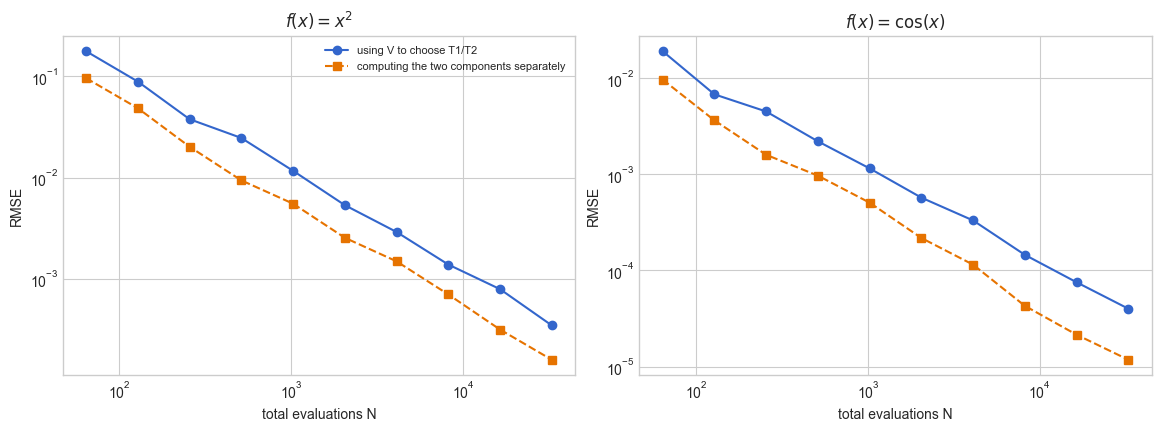

For x^2:
  using V slope = -0.98
  separate-components slope = -1.03
  at N=32,768: using V RMSE = 0.000343876
  at N=32,768: separate-components RMSE = 0.000157216
For cos(x):
  using V slope = -0.98
  separate-components slope = -1.08
  at N=32,768: using V RMSE = 4.00019e-05
  at N=32,768: separate-components RMSE = 1.17855e-05


In [4]:
sample_sizes = 2 ** np.arange(6, 16)
replications = 32
n_max = int(sample_sizes[-1])
exact = p * (mu1**2 + sigma1**2) + (1 - p) * (mu2**2 + sigma2**2)
exact_cos = (
    p * np.exp(-sigma1**2 / 2) * np.cos(mu1)
    + (1 - p) * np.exp(-sigma2**2 / 2) * np.cos(mu2)
)


def to_normal(u):
    lower = np.nextafter(0.0, 1.0)
    upper = np.nextafter(1.0, 0.0)
    return norm.ppf(np.clip(u, lower, upper))


# Keep V in the calculation. Columns are U and V, in that order.
points = DigitalNetB2(
    2, seed=20260922, replications=replications, randomize="LMS DS"
)(n_max)
z = to_normal(points[..., 0])
v = points[..., 1]
x = np.where(v <= p, mu1 + sigma1 * z, mu2 + sigma2 * z)
values_using_v = x**2
values_using_v_cos = np.cos(x)

# Compute the two component integrals separately, with N/2 points for each.
u1 = DigitalNetB2(
    1, seed=20260923, replications=replications, randomize="LMS DS"
)(n_max // 2)[..., 0]
u2 = DigitalNetB2(
    1, seed=20260924, replications=replications, randomize="LMS DS"
)(n_max // 2)[..., 0]
x1 = mu1 + sigma1 * to_normal(u1)
x2 = mu2 + sigma2 * to_normal(u2)
values_1 = x1**2
values_2 = x2**2
values_1_cos = np.cos(x1)
values_2_cos = np.cos(x2)

rmse_using_v = []
rmse_separate = []
rmse_using_v_cos = []
rmse_separate_cos = []
for n in sample_sizes:
    estimates_using_v = values_using_v[:, :n].mean(axis=1)
    estimates_separate = (
        p * values_1[:, : n // 2].mean(axis=1)
        + (1 - p) * values_2[:, : n // 2].mean(axis=1)
    )
    rmse_using_v.append(np.sqrt(np.mean((estimates_using_v - exact) ** 2)))
    rmse_separate.append(np.sqrt(np.mean((estimates_separate - exact) ** 2)))
    estimates_using_v_cos = values_using_v_cos[:, :n].mean(axis=1)
    estimates_separate_cos = (
        p * values_1_cos[:, : n // 2].mean(axis=1)
        + (1 - p) * values_2_cos[:, : n // 2].mean(axis=1)
    )
    rmse_using_v_cos.append(
        np.sqrt(np.mean((estimates_using_v_cos - exact_cos) ** 2))
    )
    rmse_separate_cos.append(
        np.sqrt(np.mean((estimates_separate_cos - exact_cos) ** 2))
    )

rmse_using_v = np.asarray(rmse_using_v)
rmse_separate = np.asarray(rmse_separate)
rmse_using_v_cos = np.asarray(rmse_using_v_cos)
rmse_separate_cos = np.asarray(rmse_separate_cos)
fit = slice(-5, None)
slope_using_v = np.polyfit(
    np.log(sample_sizes[fit]), np.log(rmse_using_v[fit]), 1
)[0]
slope_separate = np.polyfit(
    np.log(sample_sizes[fit]), np.log(rmse_separate[fit]), 1
)[0]
slope_using_v_cos = np.polyfit(
    np.log(sample_sizes[fit]), np.log(rmse_using_v_cos[fit]), 1
)[0]
slope_separate_cos = np.polyfit(
    np.log(sample_sizes[fit]), np.log(rmse_separate_cos[fit]), 1
)[0]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), layout="constrained")
for ax, errors_v, errors_separate, title in [
    (axes[0], rmse_using_v, rmse_separate, r"$f(x)=x^2$"),
    (axes[1], rmse_using_v_cos, rmse_separate_cos, r"$f(x)=\cos(x)$"),
]:
    ax.loglog(
        sample_sizes, errors_v, "o-", color="#3366CC",
        label="using V to choose T1/T2",
    )
    ax.loglog(
        sample_sizes, errors_separate, "s--", color="#E67300",
        label="computing the two components separately",
    )
    ax.set(xlabel="total evaluations N", ylabel="RMSE", title=title)
axes[0].legend(frameon=False, fontsize=8)
plt.show()

print("For x^2:")
print(f"  using V slope = {slope_using_v:.2f}")
print(f"  separate-components slope = {slope_separate:.2f}")
print(f"  at N={n_max:,}: using V RMSE = {rmse_using_v[-1]:.6g}")
print(f"  at N={n_max:,}: separate-components RMSE = {rmse_separate[-1]:.6g}")
print("For cos(x):")
print(f"  using V slope = {slope_using_v_cos:.2f}")
print(f"  separate-components slope = {slope_separate_cos:.2f}")
print(f"  at N={n_max:,}: using V RMSE = {rmse_using_v_cos[-1]:.6g}")
print(f"  at N={n_max:,}: separate-components RMSE = {rmse_separate_cos[-1]:.6g}")

## 5. What do we see?

There is a discontinuity when $V$ crosses $p$. For both $x^2$ and $\cos(x)$, keeping $V$ still gives a slope near $-1$, similar to computing the components separately. In these two examples, the switch at $V=p$ does not appear to badly damage QMC convergence.

- Computing the components separately gives the smaller RMSE at the largest $N$ for both functions.
- These two examples are not a general convergence result.
- Keeping $V$ also has the advantage that the same construction directly produces mixture samples.